In [23]:
import pandas as pd
import numpy as np
import matplotlib.pyplot as plt
from scipy.stats import linregress
import sqlite3

conn = sqlite3.connect('../data/db/bluestock_mf.db')

nav = pd.read_sql("SELECT * FROM fact_nav", conn)
fund = pd.read_sql("SELECT * FROM dim_fund", conn)
perf = pd.read_sql("SELECT * FROM fact_performance", conn)

nav['date'] = pd.to_datetime(nav['date'])
nav = nav.sort_values(['amfi_code', 'date'])

In [24]:
benchmark = pd.read_csv('../data/raw/10_benchmark_indices.csv')
print(benchmark['index_name'].unique())

<StringArray>
[        'NIFTY50',        'NIFTY100', 'NIFTY_MIDCAP150',    'BSE_SMALLCAP',
        'NIFTY500',   'CRISIL_LIQUID',     'CRISIL_GILT']
Length: 7, dtype: str


# *Compute daily returns — daily_return = nav_t / nav_t-1 − 1*

count    45960.000000
mean         0.000631
std          0.010290
min         -0.058102
25%         -0.005042
50%          0.000340
75%          0.006324
max          0.064713
Name: daily_return, dtype: float64


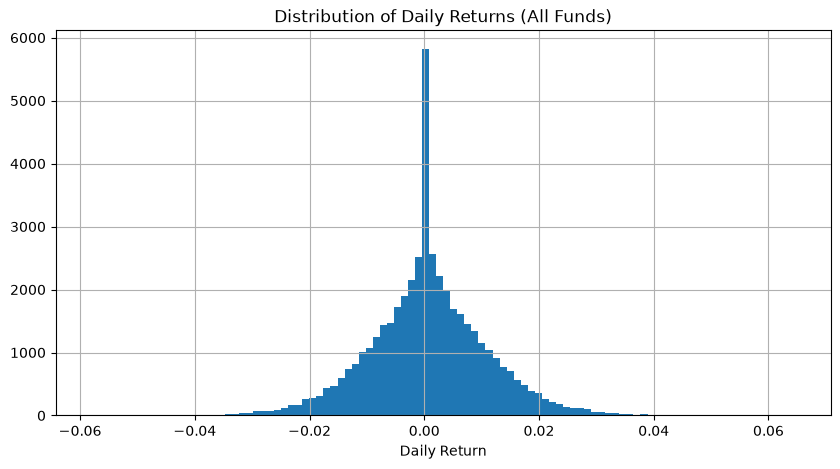

In [25]:
nav['daily_return'] = nav.groupby('amfi_code')['nav'].pct_change()

print(nav['daily_return'].describe())

plt.figure(figsize=(10,5))
nav['daily_return'].hist(bins=100)
plt.title('Distribution of Daily Returns (All Funds)')
plt.xlabel('Daily Return')
plt.savefig('../dashboard/charts/daily_returns_dist.png')
plt.show()

# *CAGR for 1yr, 3yr, 5yr — CAGR = (NAV_end / NAV_start) ^ (1/n) − 1*

In [26]:
def calc_cagr(fund_df, years):
    fund_df = fund_df.sort_values('date')
    end_date = fund_df['date'].max()
    start_date = end_date - pd.DateOffset(years=years)
    window = fund_df[fund_df['date'] >= start_date]
    if len(window) < 2:
        return np.nan
    nav_start = window.iloc[0]['nav']
    nav_end = window.iloc[-1]['nav']
    n_years = (window.iloc[-1]['date'] - window.iloc[0]['date']).days / 365.25
    return (nav_end / nav_start) ** (1/n_years) - 1

cagr_results = []
for code, group in nav.groupby('amfi_code'):
    cagr_results.append({
        'amfi_code': code,
        'cagr_1yr': calc_cagr(group, 1),
        'cagr_3yr': calc_cagr(group, 3),
        'cagr_5yr': calc_cagr(group, 5),
    })

cagr_df = pd.DataFrame(cagr_results)
cagr_df = cagr_df.merge(fund[['amfi_code','scheme_name']], on='amfi_code')
cagr_df.to_csv('../reports/cagr_report.csv', index=False)
cagr_df.head(10)

,amfi_code,cagr_1yr,cagr_3yr,cagr_5yr,scheme_name
0,100016,-0.022258,0.012924,0.026371,HDFC Top 100 Fund - Regular Plan - Growth
1,100025,0.037076,0.039155,0.044582,HDFC Short Term Debt Fund - Regular - Growth
2,100033,0.532772,0.324340,0.301232,HDFC Mid-Cap Opportunities Fund - Regular - Gr...
3,101206,0.479638,0.289602,0.235384,ABSL Frontline Equity Fund - Regular - Growth
4,101207,-0.240003,-0.041515,0.079388,ABSL Small Cap Fund - Regular - Growth
5,101208,0.072418,0.063143,0.065090,ABSL Liquid Fund - Regular - Growth
6,102885,0.202229,0.196624,0.182324,UTI Nifty 50 Index Fund - Regular - Growth
7,102886,-0.168080,-0.007672,0.011717,UTI Mid Cap Fund - Regular - Growth
8,102887,0.135930,0.255497,0.168411,UTI Flexi Cap Fund - Regular - Growth
9,118632,0.340079,0.226466,0.240495,Nippon India Large Cap Fund - Regular - Growth


# *Sharpe Ratio — (Rp − Rf) / Std(Rp) × √252*
# *Rf = 6.5% (RBI repo rate proxy)*

In [27]:
Rf = 0.065  # 6.5% annual risk-free rate

sharpe_results = []
for code, group in nav.groupby('amfi_code'):
    daily_rf = Rf / 252
    excess_return = group['daily_return'].dropna() - daily_rf
    sharpe = (excess_return.mean() / excess_return.std()) * np.sqrt(252)
    sharpe_results.append({'amfi_code': code, 'sharpe_ratio': sharpe})

sharpe_df = pd.DataFrame(sharpe_results)
sharpe_df['sharpe_rank'] = sharpe_df['sharpe_ratio'].rank(ascending=False)
sharpe_df = sharpe_df.merge(fund[['amfi_code','scheme_name']], on='amfi_code')
sharpe_df.sort_values('sharpe_ratio', ascending=False).head(10)

,amfi_code,sharpe_ratio,sharpe_rank,scheme_name
34,148567,1.448291,1.0,Mirae Asset Large Cap Fund - Regular - Growth
30,120843,1.306744,2.0,Kotak Flexicap Fund - Regular - Growth
36,148569,1.234930,3.0,Mirae Asset Tax Saver Fund - Regular - Growth
19,119551,1.208267,4.0,SBI Bluechip Fund - Regular Plan - Growth
25,120505,1.180101,5.0,ICICI Pru Midcap Fund - Regular - Growth
38,149323,1.132122,6.0,DSP Midcap Fund - Regular - Growth
2,100033,1.093699,7.0,HDFC Mid-Cap Opportunities Fund - Regular - Gr...
9,118632,1.081659,8.0,Nippon India Large Cap Fund - Regular - Growth
3,101206,1.027213,9.0,ABSL Frontline Equity Fund - Regular - Growth
24,120504,1.026524,10.0,ICICI Pru Bluechip Fund - Direct - Growth


# *Sortino Ratio*

In [28]:
sortino_results = []
for code, group in nav.groupby('amfi_code'):
    daily_rf = Rf / 252
    returns = group['daily_return'].dropna()
    excess_return = returns - daily_rf
    downside_returns = returns[returns < 0]
    downside_std = downside_returns.std()
    sortino = (excess_return.mean() / downside_std) * np.sqrt(252)
    sortino_results.append({'amfi_code': code, 'sortino_ratio': sortino})

sortino_df = pd.DataFrame(sortino_results)
sortino_df = sortino_df.merge(fund[['amfi_code','scheme_name']], on='amfi_code')
sortino_df.sort_values('sortino_ratio', ascending=False).head(10)

,amfi_code,sortino_ratio,scheme_name
34,148567,2.385644,Mirae Asset Large Cap Fund - Regular - Growth
30,120843,2.364320,Kotak Flexicap Fund - Regular - Growth
36,148569,2.146914,Mirae Asset Tax Saver Fund - Regular - Growth
19,119551,2.140267,SBI Bluechip Fund - Regular Plan - Growth
25,120505,2.029353,ICICI Pru Midcap Fund - Regular - Growth
38,149323,1.875101,DSP Midcap Fund - Regular - Growth
9,118632,1.850133,Nippon India Large Cap Fund - Regular - Growth
2,100033,1.829134,HDFC Mid-Cap Opportunities Fund - Regular - Gr...
24,120504,1.805294,ICICI Pru Bluechip Fund - Direct - Growth
3,101206,1.799563,ABSL Frontline Equity Fund - Regular - Growth


# *Alpha and Beta*

In [29]:
nifty100 = benchmark[benchmark['index_name'] == 'NIFTY100'].copy()
nifty100['date'] = pd.to_datetime(nifty100['date'])
nifty100 = nifty100.sort_values('date')
nifty100['benchmark_return'] = nifty100['close_value'].pct_change()

alpha_beta_results = []

for code, group in nav.groupby('amfi_code'):
    group = group.sort_values('date')
    merged = group.merge(nifty100[['date','benchmark_return']], on='date', how='inner')
    merged = merged.dropna(subset=['daily_return','benchmark_return'])
    
    if len(merged) < 30:
        continue
    
    slope, intercept, r_value, p_value, std_err = linregress(
        merged['benchmark_return'], merged['daily_return']
    )
    
    alpha = intercept * 252
    beta = slope
    
    alpha_beta_results.append({'amfi_code': code, 'alpha': alpha, 'beta': beta})

alpha_beta_df = pd.DataFrame(alpha_beta_results)
alpha_beta_df = alpha_beta_df.merge(fund[['amfi_code','scheme_name']], on='amfi_code')
alpha_beta_df.to_csv('../reports/alpha_beta.csv', index=False)
alpha_beta_df.sort_values('alpha', ascending=False).head(10)

,amfi_code,alpha,beta,scheme_name
21,119598,0.303370,-0.023196,SBI Small Cap Fund - Regular Plan - Growth
39,149324,0.300579,0.011455,DSP Small Cap Fund - Regular - Growth
25,120505,0.292636,0.000549,ICICI Pru Midcap Fund - Regular - Growth
36,148569,0.282704,0.018134,Mirae Asset Tax Saver Fund - Regular - Growth
30,120843,0.273305,-0.022830,Kotak Flexicap Fund - Regular - Growth
2,100033,0.271954,0.005104,HDFC Mid-Cap Opportunities Fund - Regular - Gr...
34,148567,0.269838,0.023684,Mirae Asset Large Cap Fund - Regular - Growth
38,149323,0.265986,-0.002523,DSP Midcap Fund - Regular - Growth
16,119094,0.260767,-0.066265,Axis Midcap Fund - Regular - Growth
19,119551,0.232010,-0.031751,SBI Bluechip Fund - Regular Plan - Growth


# *Maximum Drawdown — min(NAV / running_max − 1)*

In [30]:
dd_results = []
for code, group in nav.groupby('amfi_code'):
    group = group.sort_values('date')
    running_max = group['nav'].cummax()
    drawdown = group['nav'] / running_max - 1
    max_dd = drawdown.min()
    max_dd_date = group.loc[drawdown.idxmin(), 'date']
    dd_results.append({'amfi_code': code, 'max_drawdown': max_dd, 'max_dd_date': max_dd_date})

dd_df = pd.DataFrame(dd_results)
dd_df = dd_df.merge(fund[['amfi_code','scheme_name']], on='amfi_code')
dd_df.sort_values('max_drawdown').head(10)

,amfi_code,max_drawdown,max_dd_date,scheme_name
22,119599,-0.525742,2025-10-28,SBI Small Cap Fund - Direct Plan - Growth
17,119095,-0.516778,2026-05-11,Axis Small Cap Fund - Regular - Growth
4,101207,-0.354469,2026-05-11,ABSL Small Cap Fund - Regular - Growth
39,149324,-0.311719,2025-01-03,DSP Small Cap Fund - Regular - Growth
21,119598,-0.287060,2025-05-14,SBI Small Cap Fund - Regular Plan - Growth
7,102886,-0.280011,2026-04-27,UTI Mid Cap Fund - Regular - Growth
0,100016,-0.247344,2022-09-15,HDFC Top 100 Fund - Regular Plan - Growth
29,120842,-0.240035,2024-10-17,Kotak Emerging Equity Fund - Regular - Growth
11,118634,-0.233449,2026-02-20,Nippon India Small Cap Fund - Regular - Growth
15,119093,-0.217514,2023-05-22,Axis Bluechip Fund - Direct - Growth


# *Fund Scorecard (0–100)*

In [31]:
scorecard = cagr_df[['amfi_code','scheme_name','cagr_3yr']].copy()
scorecard = scorecard.merge(sharpe_df[['amfi_code','sharpe_ratio']], on='amfi_code')
scorecard = scorecard.merge(dd_df[['amfi_code','max_drawdown']], on='amfi_code')
scorecard = scorecard.merge(fund[['amfi_code','expense_ratio_pct']], on='amfi_code')
scorecard = scorecard.merge(alpha_beta_df[['amfi_code','alpha']], on='amfi_code')

scorecard['rank_return']  = scorecard['cagr_3yr'].rank(pct=True) * 100
scorecard['rank_sharpe']  = scorecard['sharpe_ratio'].rank(pct=True) * 100
scorecard['rank_alpha']   = scorecard['alpha'].rank(pct=True) * 100
scorecard['rank_expense'] = scorecard['expense_ratio_pct'].rank(pct=True, ascending=False) * 100
scorecard['rank_dd']      = scorecard['max_drawdown'].rank(pct=True, ascending=False) * 100

scorecard['score'] = (
    0.30 * scorecard['rank_return'] +
    0.25 * scorecard['rank_sharpe'] +
    0.20 * scorecard['rank_alpha'] +
    0.15 * scorecard['rank_expense'] +
    0.10 * scorecard['rank_dd']
)

scorecard = scorecard.sort_values('score', ascending=False)
scorecard.to_csv('../reports/fund_scorecard.csv', index=False)
scorecard[['scheme_name','score']].head(10)

,scheme_name,score
25,ICICI Pru Midcap Fund - Regular - Growth,84.5000
16,Axis Midcap Fund - Regular - Growth,80.7500
2,HDFC Mid-Cap Opportunities Fund - Regular - Gr...,80.5000
34,Mirae Asset Large Cap Fund - Regular - Growth,80.0000
30,Kotak Flexicap Fund - Regular - Growth,78.2500
24,ICICI Pru Bluechip Fund - Direct - Growth,75.7500
21,SBI Small Cap Fund - Regular Plan - Growth,75.1250
39,DSP Small Cap Fund - Regular - Growth,74.9375
36,Mirae Asset Tax Saver Fund - Regular - Growth,73.9375
19,SBI Bluechip Fund - Regular Plan - Growth,73.0625


# *Benchmark comparison chart + tracking error*

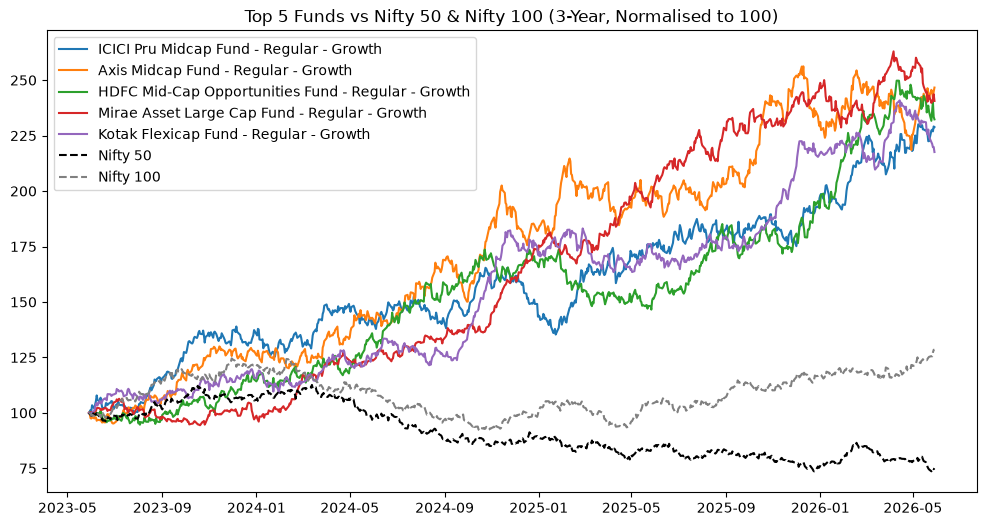


Tracking Error (vs Nifty 100):
ICICI Pru Midcap Fund - Regular - Growth: 0.2320
Axis Midcap Fund - Regular - Growth: 0.2377
HDFC Mid-Cap Opportunities Fund - Regular - Growth: 0.2287
Mirae Asset Large Cap Fund - Regular - Growth: 0.1897
Kotak Flexicap Fund - Regular - Growth: 0.2064


In [32]:
top5_codes = scorecard['amfi_code'].head(5).tolist()

nifty50 = benchmark[benchmark['index_name'] == 'NIFTY50'].copy()
nifty50['date'] = pd.to_datetime(nifty50['date'])
nifty50 = nifty50.sort_values('date')

plt.figure(figsize=(12,6))

for code in top5_codes:
    fund_data = nav[nav['amfi_code'] == code].sort_values('date').copy()
    fund_data = fund_data[fund_data['date'] >= fund_data['date'].max() - pd.DateOffset(years=3)]
    fund_data['normalised'] = fund_data['nav'] / fund_data['nav'].iloc[0] * 100
    name = fund[fund['amfi_code']==code]['scheme_name'].values[0]
    plt.plot(fund_data['date'], fund_data['normalised'], label=name)

n50_3yr = nifty50[nifty50['date'] >= nifty50['date'].max() - pd.DateOffset(years=3)].copy()
n50_3yr['normalised'] = n50_3yr['close_value'] / n50_3yr['close_value'].iloc[0] * 100
plt.plot(n50_3yr['date'], n50_3yr['normalised'], label='Nifty 50', linestyle='--', color='black')

n100_3yr = nifty100[nifty100['date'] >= nifty100['date'].max() - pd.DateOffset(years=3)].copy()
n100_3yr['normalised'] = n100_3yr['close_value'] / n100_3yr['close_value'].iloc[0] * 100
plt.plot(n100_3yr['date'], n100_3yr['normalised'], label='Nifty 100', linestyle='--', color='gray')

plt.title('Top 5 Funds vs Nifty 50 & Nifty 100 (3-Year, Normalised to 100)')
plt.legend()
plt.savefig('../dashboard/charts/benchmark_comparison.png')
plt.show()

print("\nTracking Error (vs Nifty 100):")
for code in top5_codes:
    fund_data = nav[nav['amfi_code'] == code].sort_values('date')
    merged = fund_data.merge(nifty100[['date','benchmark_return']], on='date', how='inner')
    diff = merged['daily_return'] - merged['benchmark_return']
    tracking_error = diff.std() * np.sqrt(252)
    name = fund[fund['amfi_code']==code]['scheme_name'].values[0]
    print(f"{name}: {tracking_error:.4f}")